# Basic reproduction: Mobius residuals for idioms

This notebook reproduces the core result in the paper with one model: `Qwen/Qwen3-Embedding-0.6B`. It keeps the method explicit: load the 107 curated idiom/literal pairs, compute the span-Mobius residual, compare it with simple residual baselines, and use the average residual as a held-out steering direction.

In [1]:
from pathlib import Path
import hashlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, ttest_rel
from sklearn.metrics import roc_auc_score
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

SEED = 0
ROOT = Path.cwd()

pairs = pd.read_csv(ROOT / "data" / "idiom_literal_pairs.csv").iloc[:107].copy()
pairs[["idiom_phrase", "literal_phrase", "figurative_meaning", "literal_meaning"]].head()

/Users/abel/Documents/DIEP/semanticSynergy/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,idiom_phrase,literal_phrase,figurative_meaning,literal_meaning
0,kick the bucket,kick the ball,to die,hit the sphere with your foot
1,read the room,read the book,understand a situation,parse the pages
2,break the ice,break the glass,start a conversation,shatter the window
3,spill the beans,spill the water,reveal a secret,pour out the liquid
4,bite the bullet,bite the apple,face something difficult,chew the fruit


In [2]:
MODEL_ID = "Qwen/Qwen3-Embedding-0.6B"
DEVICE = "cpu"
LOCAL_FILES_ONLY = True  # Set to False once if the Hugging Face model is not cached yet.

model = SentenceTransformer(
    MODEL_ID,
    device=DEVICE,
    trust_remote_code=True,
    local_files_only=LOCAL_FILES_ONLY,
)
model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 32768, 'do_lower_case': False, 'architecture': 'Qwen3Model'})
  (1): Pooling({'word_embedding_dimension': 1024, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': False, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': True, 'include_prompt': True})
  (2): Normalize()
)

## The residual

For a phrase `w1 ... wn`, the span-Mobius residual is

`q(w1...wn) = T(w1...wn) - T(w1...w(n-1)) - T(w2...wn) + T(w2...w(n-1))`.

For three-word idioms this is `T(w1 w2 w3) - T(w1 w2) - T(w2 w3) + T(w2)`. The last term is the overlap correction.

In [3]:
def l2norm(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-9 else v


def phrase_spans(phrase):
    words = str(phrase).split()
    if len(words) < 2:
        raise ValueError(f"Expected at least two words, got {phrase!r}")
    spans = {
        "full": " ".join(words),
        "prefix": " ".join(words[:-1]),
        "suffix": " ".join(words[1:]),
    }
    if len(words) > 2:
        spans["middle"] = " ".join(words[1:-1])
    return spans


def texts_needed_for_phrase(phrase):
    return list(phrase_spans(phrase).values()) + str(phrase).split()


embedding_cache = {}


def preload(texts):
    missing = []
    seen = set()
    for text in texts:
        text = str(text)
        if text not in embedding_cache and text not in seen:
            missing.append(text)
            seen.add(text)
    if missing:
        vectors = model.encode(
            missing,
            convert_to_numpy=True,
            batch_size=64,
            normalize_embeddings=False,
            show_progress_bar=True,
        )
        embedding_cache.update(dict(zip(missing, vectors)))


def emb(text):
    text = str(text)
    if text not in embedding_cache:
        preload([text])
    return embedding_cache[text]


def span_residuals(phrase):
    words = str(phrase).split()
    spans = phrase_spans(phrase)
    full = emb(spans["full"])
    prefix = emb(spans["prefix"])
    suffix = emb(spans["suffix"])
    middle = emb(spans["middle"]) if "middle" in spans else 0.0
    unigrams = np.vstack([emb(word) for word in words])

    return {
        "mobius": full - prefix - suffix + middle,
        "bigram_only": full - prefix - suffix,
        "unigram_sum": full - unigrams.sum(axis=0),
        "unigram_mean": full - unigrams.mean(axis=0),
        "phrase_only": full,
    }


def stable_seed(text):
    digest = hashlib.sha256(str(text).encode("utf-8")).digest()
    return int.from_bytes(digest[:8], "little") % (2**31)


def score_residuals_against_meaning(phrase, meaning):
    residuals = span_residuals(phrase)
    q = residuals["mobius"]
    rng = np.random.default_rng([SEED, stable_seed(phrase)])
    random_vec = l2norm(rng.standard_normal(q.shape[0])) * np.linalg.norm(q)
    residuals["random"] = random_vec

    target = emb(meaning)
    return {name: float(np.dot(vec, target)) for name, vec in residuals.items()}


all_words = sorted({
    word
    for phrase in pd.concat([pairs["idiom_phrase"], pairs["literal_phrase"]])
    for word in str(phrase).split()
})
rng = np.random.default_rng(SEED)
random_triplets = [" ".join(rng.choice(all_words, size=3, replace=False)) for _ in range(len(pairs))]
generic_meaning = "a random combination of words"

texts = set()
for _, row in pairs.iterrows():
    for phrase in [row["idiom_phrase"], row["literal_phrase"]]:
        texts.update(texts_needed_for_phrase(phrase))
    texts.add(row["figurative_meaning"])
    texts.add(row["literal_meaning"])
for phrase in random_triplets:
    texts.update(texts_needed_for_phrase(phrase))
texts.add(generic_meaning)

preload(sorted(texts))
len(embedding_cache)

Batches: 100%|██████████| 20/20 [00:07<00:00,  2.80it/s]


1273

## Idiom detection and residual baselines

The score is the inner product between a residual vector and the target meaning embedding. Idioms should score higher than matched literal controls when the residual isolates non-compositional meaning.

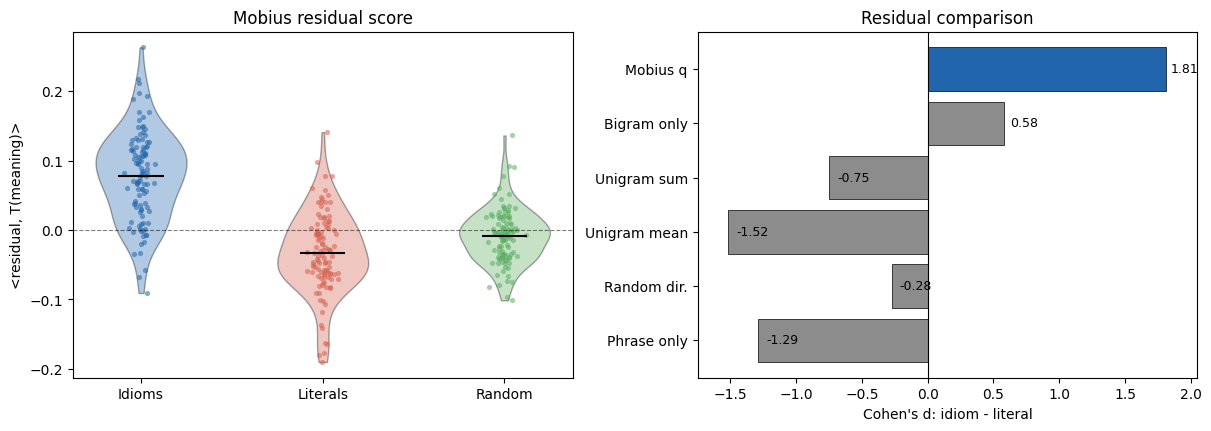

,residual,idiom_mean,literal_mean,cohens_d,p_value,roc_auc
0,mobius,0.078129,-0.033245,1.810478,1.646440e-29,0.900777
1,bigram_only,-0.583545,-0.633253,0.583483,2.976762e-05,0.673771
2,unigram_sum,-1.255709,-1.141127,-0.748897,1.227618e-07,0.305442
3,unigram_mean,0.001499,0.118392,-1.515519,9.145975e-23,0.135383
4,random,-0.000147,0.004980,-0.275123,4.545400e-02,0.420910
5,phrase_only,0.630103,0.745300,-1.290376,7.127105e-18,0.174862


In [4]:
rows = []
for _, row in pairs.iterrows():
    examples = [
        ("idiom", row["idiom_phrase"], row["figurative_meaning"]),
        ("literal", row["literal_phrase"], row["literal_meaning"]),
    ]
    for kind, phrase, meaning in examples:
        for residual, score in score_residuals_against_meaning(phrase, meaning).items():
            rows.append({"kind": kind, "phrase": phrase, "residual": residual, "score": score})

for phrase in random_triplets:
    for residual, score in score_residuals_against_meaning(phrase, generic_meaning).items():
        rows.append({"kind": "random", "phrase": phrase, "residual": residual, "score": score})

scores = pd.DataFrame(rows)


def cohens_d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return float((a.mean() - b.mean()) / pooled)


residual_order = ["mobius", "bigram_only", "unigram_sum", "unigram_mean", "random", "phrase_only"]
residual_labels = {
    "mobius": "Mobius q",
    "bigram_only": "Bigram only",
    "unigram_sum": "Unigram sum",
    "unigram_mean": "Unigram mean",
    "random": "Random dir.",
    "phrase_only": "Phrase only",
}

summary_rows = []
for residual in residual_order:
    idiom_scores = scores[(scores.kind == "idiom") & (scores.residual == residual)].score.to_numpy()
    literal_scores = scores[(scores.kind == "literal") & (scores.residual == residual)].score.to_numpy()
    y_true = np.r_[np.ones_like(idiom_scores), np.zeros_like(literal_scores)]
    y_score = np.r_[idiom_scores, literal_scores]
    summary_rows.append({
        "residual": residual,
        "idiom_mean": idiom_scores.mean(),
        "literal_mean": literal_scores.mean(),
        "cohens_d": cohens_d(idiom_scores, literal_scores),
        "p_value": ttest_ind(idiom_scores, literal_scores, equal_var=False).pvalue,
        "roc_auc": roc_auc_score(y_true, y_score),
    })
summary = pd.DataFrame(summary_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

ax = axes[0]
kind_order = ["idiom", "literal", "random"]
kind_labels = ["Idioms", "Literals", "Random"]
kind_colors = ["#2166ac", "#d6604d", "#5aae61"]
plot_data = [
    scores[(scores.kind == kind) & (scores.residual == "mobius")].score.to_numpy()
    for kind in kind_order
]
violins = ax.violinplot(plot_data, showmeans=True, showextrema=False)
for body, color in zip(violins["bodies"], kind_colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.35)
violins["cmeans"].set_color("black")
for x, vals, color in zip(range(1, 4), plot_data, kind_colors):
    jitter = np.random.default_rng(SEED + x).normal(0, 0.035, size=len(vals))
    ax.scatter(x + jitter, vals, s=14, color=color, alpha=0.55, linewidth=0)
ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(kind_labels)
ax.set_ylabel("<residual, T(meaning)>")
ax.set_title("Mobius residual score")

ax = axes[1]
bar_summary = summary.set_index("residual").loc[residual_order].iloc[::-1]
labels = [residual_labels[r] for r in bar_summary.index]
colors = ["#2166ac" if r == "mobius" else "#8c8c8c" for r in bar_summary.index]
ax.barh(labels, bar_summary.cohens_d, color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Cohen's d: idiom - literal")
ax.set_title("Residual comparison")
ax.set_xlim(-1.75, 2.05)
for y, value in enumerate(bar_summary.cohens_d):
    if value >= 0:
        ax.text(value + 0.04, y, f"{value:.2f}", va="center", ha="left", fontsize=9)
    else:
        ax.text(value + 0.06, y, f"{value:.2f}", va="center", ha="left", fontsize=9)
plt.show()
summary

## Held-out steering

For each random 80/20 split, build directions on the training idioms only and evaluate the idiomaticity index on the held-out idioms:

`Delta = cos(z, T(figurative meaning)) - cos(z, T(literal paraphrase))`.

Steering uses `z' = norm(z +/- alpha c)` with `alpha = 5`.

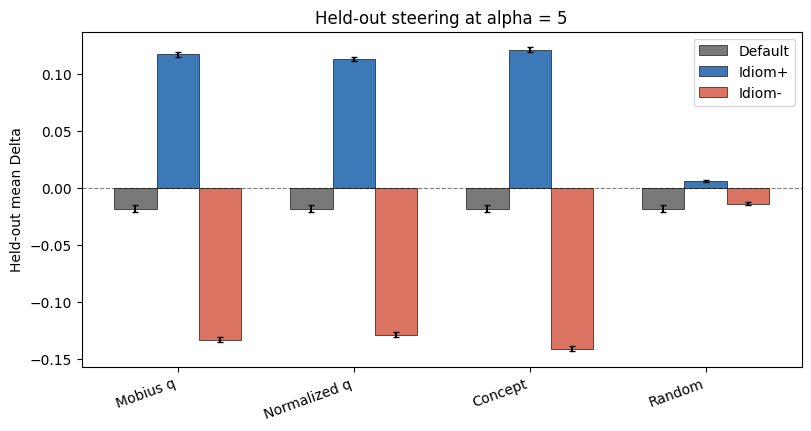

condition,Default,Idiom+,Idiom-,p_idiom_plus_vs_minus
direction,,,,
Mobius q,-0.018021,0.117419,-0.132934,1.734641e-190
Normalized q,-0.018021,0.113468,-0.128496,5.463042e-189
Concept,-0.018021,0.121701,-0.140916,4.791413e-182
Random,-0.018021,0.006587,-0.013634,5.027473e-59


In [5]:
def cosine(a, b):
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb)) if na > 1e-9 and nb > 1e-9 else 0.0


def delta_index(z, figurative_target, literal_target):
    return cosine(z, figurative_target) - cosine(z, literal_target)


def steer(z, direction, sign, alpha):
    return l2norm(z + sign * alpha * direction)


def make_splits(n_items, n_splits=200, train_fraction=0.80):
    rng = np.random.default_rng(SEED)
    train_n = int(round(train_fraction * n_items))
    for split_id in range(n_splits):
        perm = rng.permutation(n_items)
        yield split_id, np.sort(perm[:train_n]), np.sort(perm[train_n:])


ALPHA = 5.0
N_SPLITS = 200

E_idiom = np.vstack([emb(row["idiom_phrase"]) for _, row in pairs.iterrows()])
E_literal = np.vstack([emb(row["literal_phrase"]) for _, row in pairs.iterrows()])
E_fig = np.vstack([emb(row["figurative_meaning"]) for _, row in pairs.iterrows()])
E_lit = np.vstack([emb(row["literal_meaning"]) for _, row in pairs.iterrows()])
Q_idiom = np.vstack([span_residuals(row["idiom_phrase"])["mobius"] for _, row in pairs.iterrows()])

base_delta = np.array([delta_index(E_idiom[i], E_fig[i], E_lit[i]) for i in range(len(pairs))])
random_direction = l2norm(np.random.default_rng(SEED).standard_normal(E_idiom.shape[1]))

split_rows = []
for split_id, train_idx, test_idx in make_splits(len(pairs), N_SPLITS):
    q_train = Q_idiom[train_idx]
    directions = {
        "Mobius q": l2norm(q_train.mean(axis=0)),
        "Normalized q": l2norm(np.vstack([l2norm(q) for q in q_train]).mean(axis=0)),
        "Concept": l2norm(E_idiom[train_idx].mean(axis=0) - E_literal[train_idx].mean(axis=0)),
        "Random": random_direction,
    }
    for direction_name, direction in directions.items():
        values = {
            "Default": base_delta[test_idx],
            "Idiom+": np.array([
                delta_index(steer(E_idiom[i], direction, +1, ALPHA), E_fig[i], E_lit[i])
                for i in test_idx
            ]),
            "Idiom-": np.array([
                delta_index(steer(E_idiom[i], direction, -1, ALPHA), E_fig[i], E_lit[i])
                for i in test_idx
            ]),
        }
        for condition, vals in values.items():
            split_rows.append({
                "split": split_id,
                "direction": direction_name,
                "condition": condition,
                "delta": vals.mean(),
            })

steering_splits = pd.DataFrame(split_rows)

direction_order = ["Mobius q", "Normalized q", "Concept", "Random"]
condition_order = ["Default", "Idiom+", "Idiom-"]
condition_colors = {"Default": "#666666", "Idiom+": "#2166ac", "Idiom-": "#d6604d"}

overall_rows = []
p_rows = []
for direction_name, grp in steering_splits.groupby("direction"):
    pivot = grp.pivot(index="split", columns="condition", values="delta")
    p_plus_minus = ttest_rel(pivot["Idiom+"], pivot["Idiom-"]).pvalue
    p_rows.append({"direction": direction_name, "p_idiom_plus_vs_minus": p_plus_minus})
    for condition in condition_order:
        vals = pivot[condition].to_numpy()
        sem = vals.std(ddof=1) / np.sqrt(len(vals))
        overall_rows.append({
            "direction": direction_name,
            "condition": condition,
            "mean_delta": vals.mean(),
            "ci_low": vals.mean() - 1.96 * sem,
            "ci_high": vals.mean() + 1.96 * sem,
        })

steering = pd.DataFrame(overall_rows)
p_values = pd.DataFrame(p_rows).set_index("direction")

fig, ax = plt.subplots(figsize=(8, 4.2), constrained_layout=True)
x = np.arange(len(direction_order))
width = 0.24
offsets = {"Default": -width, "Idiom+": 0.0, "Idiom-": width}
for condition in condition_order:
    rows = steering[(steering.condition == condition)].set_index("direction").loc[direction_order]
    y = rows.mean_delta.to_numpy()
    yerr = np.vstack([y - rows.ci_low.to_numpy(), rows.ci_high.to_numpy() - y])
    ax.bar(
        x + offsets[condition],
        y,
        width=width,
        yerr=yerr,
        capsize=2,
        label=condition,
        color=condition_colors[condition],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.88,
    )
ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(direction_order, rotation=20, ha="right")
ax.set_ylabel("Held-out mean Delta")
ax.set_title("Held-out steering at alpha = 5")
ax.legend(frameon=True)
plt.show()

steering_table = steering.pivot(index="direction", columns="condition", values="mean_delta").loc[direction_order, condition_order]
steering_table["p_idiom_plus_vs_minus"] = p_values.loc[direction_order, "p_idiom_plus_vs_minus"]
steering_table